# Quasi-Newton Methods BFGS and L-BFGS: Implementation and Comparison

**Course:** Advanced Numerical Optimization (20.IDI16) · **Mentor:** Prof. Marko Miladinović · **Author:** Elvir Muslić

Steepest descent, BFGS and L-BFGS with a strong Wolfe line search, verified against the theory and compared on
15 test functions from Vilin, the optimization framework of the course. Run with
`.venv/bin/jupyter nbconvert --to notebook --execute --inplace bfgs_lbfgs_project.ipynb`
(the reported run took 90.9 s on a heavily loaded machine). The run writes the figures to `figures/` and the key numbers to `results.json`.

In [1]:
import os
for var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[var] = "1"            # single-threaded BLAS, so timings of the methods are comparable

import json
import platform
import time
from collections import deque
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import scipy.optimize
import torch
from scipy.linalg import blas

NOTEBOOK_START = time.perf_counter()
torch.set_num_threads(1)
torch.set_default_dtype(torch.float64)
np.set_printoptions(precision=6, suppress=False)
pd.set_option("display.width", 160)

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "font.size": 8, "axes.titlesize": 9, "axes.labelsize": 8,
    "legend.fontsize": 7, "xtick.labelsize": 7, "ytick.labelsize": 7, "lines.linewidth": 1.2,
    "axes.grid": True, "grid.linestyle": ":", "grid.alpha": 0.6, "pdf.fonttype": 42,
})
COLORS = {"Steepest descent": "0.45", "BFGS": "C0", "L-BFGS (m=5)": "C1", "L-BFGS (m=10)": "C2"}

RESULTS = {"environment": {
    "python": platform.python_version(), "numpy": np.__version__, "scipy": scipy.__version__,
    "torch": torch.__version__, "matplotlib": matplotlib.__version__, "machine": platform.machine(),
}}


def check(condition, message):
    """Fail loudly if a verification does not hold; otherwise print it."""
    assert condition, f"check failed: {message}"
    print(f"check: {message} ✓")


def save_figure(fig, name):
    fig.savefig(FIG_DIR / name, bbox_inches="tight")
    plt.show()


print({k: v for k, v in RESULTS["environment"].items()})

{'python': '3.14.1', 'numpy': '2.5.0', 'scipy': '1.18.0', 'torch': '2.14.1', 'matplotlib': '3.11.0', 'machine': 'arm64'}


## 1. Theory (brief)

We minimize a smooth $f:\mathbb{R}^n\to\mathbb{R}$ by $x_{k+1}=x_k+\alpha_k p_k$ with $p_k=-H_k\nabla f_k$, where
$H_k\approx\nabla^2 f(x_k)^{-1}$. Quasi-Newton methods are covered in the course book of Miladinović and Stanimirović;
L-BFGS and the notation follow Nocedal and Wright.

**Secant equation.** With $s_k=x_{k+1}-x_k$ and $y_k=\nabla f_{k+1}-\nabla f_k$, the next approximation must satisfy
$H_{k+1}y_k=s_k$. A symmetric positive definite solution exists only under the **curvature condition** $s_k^\top y_k>0$.

**BFGS update** (inverse form), with $\rho_k=1/(y_k^\top s_k)$:
$$H_{k+1}=(I-\rho_k s_k y_k^\top)\,H_k\,(I-\rho_k y_k s_k^\top)+\rho_k s_k s_k^\top .$$

**Theorem.** If $H_k$ is symmetric positive definite and $s_k^\top y_k>0$, then $H_{k+1}$ is symmetric, satisfies the
secant equation $H_{k+1}y_k=s_k$, and is positive definite. For $z\neq 0$,
$z^\top H_{k+1}z=(V_kz)^\top H_k(V_kz)+\rho_k(s_k^\top z)^2$ with $V_k=I-\rho_k y_k s_k^\top$; both terms are nonnegative and
they cannot vanish together.

**Strong Wolfe conditions** ($c_1=10^{-4}$, $c_2=0.9$):
$$f(x_k+\alpha p_k)\le f_k+c_1\alpha\nabla f_k^\top p_k,\qquad |\nabla f(x_k+\alpha p_k)^\top p_k|\le c_2|\nabla f_k^\top p_k| .$$
The second condition gives $s_k^\top y_k\ge (c_2-1)\alpha_k\nabla f_k^\top p_k>0$, so every BFGS update stays positive definite.

**L-BFGS** keeps only the last $m$ pairs $(s_i,y_i)$ and computes $H_k\nabla f_k$ by the **two-loop recursion** in $O(mn)$
operations, with $H_k^0=\gamma_k I$ and $\gamma_k=s_{k-1}^\top y_{k-1}/y_{k-1}^\top y_{k-1}$:

$q\leftarrow\nabla f_k$; for $i=k-1,\dots,k-m$: $\alpha_i\leftarrow\rho_i s_i^\top q$, $q\leftarrow q-\alpha_i y_i$;
$r\leftarrow\gamma_k q$; for $i=k-m,\dots,k-1$: $\beta\leftarrow\rho_i y_i^\top r$, $r\leftarrow r+(\alpha_i-\beta)s_i$; then $r=H_k\nabla f_k$.

Memory is $2mn$ numbers instead of the $n^2$ of BFGS.

**Rates.** Steepest descent converges linearly. Under standard assumptions BFGS converges **superlinearly** near a minimizer with positive
definite Hessian (Dennis and Moré): $\|x_{k+1}-x^*\|/\|x_k-x^*\|\to 0$.

## 2. Implementation

* **Line search.** Strong Wolfe search by Nocedal and Wright, Algorithms 3.5 (bracketing) and 3.6 (zoom). Inside the
  bracket it uses cubic interpolation when both end slopes are known, quadratic interpolation otherwise, and bisection as
  a safeguard. The gradient is evaluated only after sufficient decrease holds, so function and gradient evaluations are
  counted separately.
* **Steepest descent.** First trial step $\alpha_{k-1}\nabla f_{k-1}^\top p_{k-1}/\nabla f_k^\top p_k$ (N&W §3.5).
* **BFGS.** The first step goes along $-\nabla f_0$; before the first update $H_0=(y_0^\top s_0/y_0^\top y_0)\,I$ (N&W 6.20).
  The update is applied as the equivalent symmetric rank-2 correction $H+sw^\top+ws^\top$ with BLAS `dsymv`/`dsyr2`,
  which costs $O(n^2)$ per iteration and creates no $n\times n$ temporaries.
* **L-BFGS($m$).** Two-loop recursion with the $\gamma_k$ scaling. The default $m=5$ is also Vilin's default.
* **Trial step.** $\min(1,1/\|\nabla f_0\|)$ in the first iteration, then $1$ for the quasi-Newton methods.
* **Stopping test.** $\|\nabla f_k\|_2\le 10^{-5}\max(1,\|x_k\|_2)$, the test (2.8) with which Liu and
  Nocedal terminated their runs, chosen for low accuracy, or 10 000 iterations. Section 5.0 compares it with two common alternatives.

Differences from Vilin's MATLAB code (defaults in `presets.m`): Vilin's BFGS uses a weak Wolfe search ($c_2=0.9$) and its
L-BFGS the Moré–Thuente search; its strong Wolfe search uses $c_2=0.1$; from the second iteration its Wolfe searches start at
$\min(1,1.01\,|2(f_k-f_{k-1})/\nabla f_k^\top p_k|)$. Its BFGS starts from $H_0=I$ without scaling, neither method skips updates or
restarts, and both stop on $\|\nabla f\|_2\le\varepsilon$ together with a relative change test on $f$. Vilin's L-BFGS keeps $m=5$
pairs with the same $\gamma_k$ scaling.

In [2]:
class CountedObjective:
    """Wraps f and its gradient and counts evaluations of each."""

    def __init__(self, fun, grad):
        self.fun, self.grad_fun = fun, grad
        self.nfev = 0
        self.ngev = 0

    def f(self, x):
        self.nfev += 1
        with np.errstate(over="ignore", invalid="ignore"):
            return float(self.fun(x))

    def g(self, x):
        self.ngev += 1
        return self.grad_fun(x)


def _interpolate(a_lo, f_lo, d_lo, a_hi, f_hi, d_hi):
    """Minimizer of the cubic (or, without d_hi, quadratic) interpolant on [a_lo, a_hi]."""
    if not np.isfinite(f_hi):
        return None
    if d_hi is not None:
        d1 = d_lo + d_hi - 3.0 * (f_lo - f_hi) / (a_lo - a_hi)
        rad = d1 * d1 - d_lo * d_hi
        if rad >= 0.0:
            d2 = np.copysign(np.sqrt(rad), a_hi - a_lo)
            den = d_hi - d_lo + 2.0 * d2
            if den != 0.0:
                return a_hi - (a_hi - a_lo) * (d_hi + d2 - d1) / den
    h = a_hi - a_lo
    c = (f_hi - f_lo - d_lo * h) / (h * h)
    if c > 0.0:
        return a_lo - d_lo / (2.0 * c)
    return None


def strong_wolfe(obj, x, p, f0, g0, alpha0, c1=1e-4, c2=0.9, max_iter=60):
    """Line search satisfying the strong Wolfe conditions (N&W Algorithms 3.5 and 3.6).

    Returns (alpha, f(x + alpha p), grad(x + alpha p), satisfied)."""
    dphi0 = float(g0 @ p)

    def zoom(lo, hi):
        # lo = (alpha, f, dphi, grad) satisfies sufficient decrease; hi = (alpha, f, dphi or None)
        for _ in range(max_iter):
            a_lo, f_lo, d_lo, g_lo = lo
            a_hi, f_hi, d_hi = hi
            a = _interpolate(a_lo, f_lo, d_lo, a_hi, f_hi, d_hi)
            left, right = min(a_lo, a_hi), max(a_lo, a_hi)
            width = right - left
            if a is None or not (left + 0.1 * width <= a <= right - 0.1 * width):
                a = 0.5 * (a_lo + a_hi)                      # safeguard: bisection
            fa = obj.f(x + a * p)
            if not np.isfinite(fa) or fa > f0 + c1 * a * dphi0 or fa >= f_lo:
                hi = (a, fa, None)
            else:
                ga = obj.g(x + a * p)
                da = float(ga @ p)
                if abs(da) <= -c2 * dphi0:
                    return a, fa, ga, True
                if da * (a_hi - a_lo) >= 0.0:
                    hi = (a_lo, f_lo, d_lo)
                lo = (a, fa, da, ga)
            if abs(hi[0] - lo[0]) <= 1e-16 * max(1.0, abs(lo[0])):
                break
        a_lo, f_lo, _, g_lo = lo                              # best point with sufficient decrease
        return a_lo, f_lo, g_lo, False

    prev = (0.0, f0, dphi0, g0)
    a = alpha0
    for i in range(max_iter):
        fa = obj.f(x + a * p)
        if not np.isfinite(fa) or fa > f0 + c1 * a * dphi0 or (i > 0 and fa >= prev[1]):
            return zoom(prev, (a, fa, None))
        ga = obj.g(x + a * p)
        da = float(ga @ p)
        if abs(da) <= -c2 * dphi0:
            return a, fa, ga, True
        if da >= 0.0:
            return zoom((a, fa, da, ga), (prev[0], prev[1], prev[2]))
        prev = (a, fa, da, ga)
        a *= 2.0
    return prev[0], prev[1], prev[3], False


def bfgs_update(H, s, y):
    """Explicit BFGS inverse update (N&W 6.17): (I - rho s y^T) H (I - rho y s^T) + rho s s^T."""
    rho = 1.0 / (y @ s)
    V = np.eye(len(s)) - rho * np.outer(y, s)
    return V.T @ H @ V + rho * np.outer(s, s)


def bfgs_update_rank2(H_upper, s, y):
    """Same update as a symmetric rank-2 correction H + s w^T + w s^T, in place on the upper triangle
    (BLAS dsymv/dsyr2, O(n^2) work, no n x n temporaries)."""
    rho = 1.0 / (y @ s)
    hy = blas.dsymv(1.0, H_upper, y, lower=0)
    w = -rho * hy + 0.5 * (rho * rho * (y @ hy) + rho) * s
    return blas.dsyr2(1.0, s, w, a=H_upper, lower=0, overwrite_a=1)


def two_loop(g, pairs, gamma):
    """L-BFGS two-loop recursion (N&W Algorithm 7.4): returns H_k g with H_k^0 = gamma I."""
    q = g.copy()
    alphas = []
    for s, y, rho in reversed(pairs):
        a = rho * (s @ q)
        alphas.append(a)
        q -= a * y
    r = gamma * q
    for (s, y, rho), a in zip(pairs, reversed(alphas)):
        b = rho * (y @ r)
        r += (a - b) * s
    return r


@dataclass
class Result:
    method: str
    x: np.ndarray
    f: float
    gnorm: float
    iterations: int
    nfev: int
    ngev: int
    time: float
    status: str                     # "converged", "max_iter" or "line_search"
    gnorm_history: list = field(default_factory=list)
    x_history: list = field(default_factory=list)

    @property
    def converged(self):
        return self.status == "converged"


def minimize(fun, grad, x0, method="lbfgs", m=5, eps=1e-5, max_iter=10_000, keep_x=False, stop="rel_x"):
    """Minimize f from x0.

    Stopping rule (stop="rel_x", default): ||g_k||_2 <= eps * max(1, ||x_k||_2), as in the L-BFGS code of
    Liu and Nocedal. Alternatives kept for comparison: "rel_g0" (||g_k||_2 <= eps * max(1, ||g_0||_2))
    and "abs_inf" (||g_k||_inf <= eps).

    method: "sd" (steepest descent), "bfgs", or "lbfgs" (memory m)."""
    obj = CountedObjective(fun, grad)
    t_start = time.perf_counter()
    x = np.array(x0, dtype=float)
    f = obj.f(x)
    g = obj.g(x)
    gnorm = float(np.linalg.norm(g))
    tol = eps * max(1.0, gnorm)
    hist, xs = [gnorm], ([x.copy()] if keep_x else [])
    n = x.size
    H = None                                    # BFGS: upper triangle of H_k (Fortran order)
    pairs, gamma = deque(maxlen=m), 1.0         # L-BFGS memory
    prev_step = None                            # steepest descent: (alpha, g^T p) of the last step
    status, k = "max_iter", 0
    def done():
        if stop == "abs_inf":
            return float(np.max(np.abs(g))) <= eps
        if stop == "rel_x":
            return gnorm <= eps * max(1.0, float(np.linalg.norm(x)))
        return gnorm <= tol
    while k < max_iter:
        if done():
            status = "converged"
            break
        if method == "sd" or (method == "bfgs" and H is None) or (method == "lbfgs" and not pairs):
            p = -g
        elif method == "bfgs":
            p = -blas.dsymv(1.0, H, g, lower=0)
        else:
            p = -two_loop(g, list(pairs), gamma)
        if g @ p >= 0.0:                        # not a descent direction (numerically): restart
            p, H = -g, None
            pairs.clear()
        if k == 0:
            alpha0 = min(1.0, 1.0 / gnorm)
        elif method == "sd":
            a_prev, slope_prev = prev_step
            alpha0 = a_prev * slope_prev / float(g @ p)      # N&W §3.5
        else:
            alpha0 = 1.0
        alpha, f_new, g_new, ok = strong_wolfe(obj, x, p, f, g, alpha0)
        if alpha == 0.0:
            status = "line_search"
            break
        s = alpha * p
        y = g_new - g
        sy = float(s @ y)
        if method == "sd":
            prev_step = (alpha, float(g @ p))
        elif sy > 1e-12 * np.linalg.norm(s) * np.linalg.norm(y):
            if method == "bfgs":
                if H is None:                                # H_0 = (s^T y / y^T y) I  (N&W 6.20)
                    H = np.asfortranarray(np.eye(n) * (sy / float(y @ y)))
                H = bfgs_update_rank2(H, s, y)
            else:
                pairs.append((s, y, 1.0 / sy))
                gamma = sy / float(y @ y)
        x = x + s
        f, g = f_new, g_new
        gnorm = float(np.linalg.norm(g))
        k += 1
        hist.append(gnorm)
        if keep_x:
            xs.append(x.copy())
    if status == "max_iter" and done():
        status = "converged"
    name = {"sd": "Steepest descent", "bfgs": "BFGS", "lbfgs": f"L-BFGS (m={m})"}[method]
    return Result(name, x, f, gnorm, k, obj.nfev, obj.ngev, time.perf_counter() - t_start, status, hist, xs)

## 3. Verification

Three checks of the formulas before any experiment: the worked update from the seminar paper, the theorem on random data,
and the two-loop recursion against the explicit BFGS matrix.

In [3]:
# 3.1 Worked update from the seminar paper: H = I, s = (1, 0), y = (2, 1)
s_w, y_w = np.array([1.0, 0.0]), np.array([2.0, 1.0])
H_w = bfgs_update(np.eye(2), s_w, y_w)
eig_w = np.linalg.eigvalsh(H_w)
print("H_{k+1} =\n", H_w)
check(np.allclose(H_w, [[0.75, -0.5], [-0.5, 1.0]], atol=1e-15), "H_{k+1} = [[3/4, -1/2], [-1/2, 1]]")
check(np.allclose(H_w @ y_w, s_w, atol=1e-15), "secant equation H_{k+1} y = s")
check(np.allclose(eig_w, [0.3596, 1.3904], atol=5e-5), f"eigenvalues {eig_w[0]:.4f}, {eig_w[1]:.4f} > 0")

# 3.2 The theorem on 1000 random pairs with s^T y > 0, and the rank-2 form used by the solver
rng = np.random.default_rng(16)
sym_err, sec_err, min_eig, rank2_err = 0.0, 0.0, np.inf, 0.0
for _ in range(1000):
    n_r = int(rng.integers(2, 11))
    A = rng.standard_normal((n_r, n_r))
    H_r = A @ A.T + 0.1 * np.eye(n_r)
    while True:
        s_r, y_r = rng.standard_normal(n_r), rng.standard_normal(n_r)
        y_r = y_r if s_r @ y_r > 0 else -y_r
        if s_r @ y_r >= 0.05 * np.linalg.norm(s_r) * np.linalg.norm(y_r):
            break
    H_new = bfgs_update(H_r, s_r, y_r)
    sym_err = max(sym_err, np.max(np.abs(H_new - H_new.T)) / np.max(np.abs(H_new)))
    sec_err = max(sec_err, np.linalg.norm(H_new @ y_r - s_r) / np.linalg.norm(s_r))
    min_eig = min(min_eig, np.linalg.eigvalsh(H_new).min())
    H_up = bfgs_update_rank2(np.asfortranarray(H_r.copy()), s_r, y_r)
    H_full = np.triu(H_up) + np.triu(H_up, 1).T
    rank2_err = max(rank2_err, np.max(np.abs(H_full - H_new)) / np.max(np.abs(H_new)))
check(sym_err <= 1e-14, f"symmetry on 1000 pairs: max relative asymmetry {sym_err:.1e}")
check(sec_err <= 1e-12, f"secant equation on 1000 pairs: max relative residual {sec_err:.1e}")
check(min_eig > 0, f"positive definiteness on 1000 pairs: smallest eigenvalue {min_eig:.2e} > 0")
check(rank2_err <= 1e-12, f"BLAS rank-2 form equals the explicit formula: max relative difference {rank2_err:.1e}")

# 3.3 Two-loop recursion against the explicit matrix built from the same m pairs
n_t, m_t = 7, 6
pairs_t = []
for _ in range(m_t):
    s_t, y_t = rng.standard_normal(n_t), rng.standard_normal(n_t)
    y_t = y_t if s_t @ y_t > 0 else -y_t
    pairs_t.append((s_t, y_t, 1.0 / (s_t @ y_t)))
gamma_t = (pairs_t[-1][0] @ pairs_t[-1][1]) / (pairs_t[-1][1] @ pairs_t[-1][1])
H_t = gamma_t * np.eye(n_t)
for s_t, y_t, _ in pairs_t:
    H_t = bfgs_update(H_t, s_t, y_t)
g_t = rng.standard_normal(n_t)
two_loop_err = np.linalg.norm(two_loop(g_t, pairs_t, gamma_t) - H_t @ g_t) / np.linalg.norm(H_t @ g_t)
check(two_loop_err <= 1e-10, f"two-loop direction equals the explicit BFGS direction: relative difference {two_loop_err:.1e}")

RESULTS["verification"] = {
    "worked_update": {"H_next": H_w.tolist(), "eigenvalues": eig_w.tolist(),
                      "secant_residual": float(np.linalg.norm(H_w @ y_w - s_w))},
    "theorem_1000_pairs": {"max_rel_asymmetry": sym_err, "max_rel_secant_residual": sec_err,
                           "min_eigenvalue": float(min_eig), "rank2_vs_explicit": rank2_err},
    "two_loop_vs_explicit": float(two_loop_err),
}

H_{k+1} =
 [[ 0.75 -0.5 ]
 [-0.5   1.  ]]
check: H_{k+1} = [[3/4, -1/2], [-1/2, 1]] ✓
check: secant equation H_{k+1} y = s ✓
check: eigenvalues 0.3596, 1.3904 > 0 ✓
check: symmetry on 1000 pairs: max relative asymmetry 4.2e-16 ✓
check: secant equation on 1000 pairs: max relative residual 4.3e-13 ✓
check: positive definiteness on 1000 pairs: smallest eigenvalue 6.92e-03 > 0 ✓
check: BLAS rank-2 form equals the explicit formula: max relative difference 2.8e-15 ✓
check: two-loop direction equals the explicit BFGS direction: relative difference 2.9e-15 ✓


## 4. Test set from Vilin

Fifteen functions from Vilin (`Functions/MultiDimensional/*.m`, MIT license, P. Živadinović and M. Miladinović,
github.com/markomil/vilin-numerical-optimization). As its authors state (Miladinović and Živadinović 2018), Vilin's
functions are mostly taken from Andrei's collection (Andrei 2008); all fifteen used here appear in it, and seven are
labelled there and in Vilin as CUTE functions (Bongartz et al. 1995). Values and gradients are ported to NumPy in vectorized form, and the starting points are
Vilin's (`Util/StartingPointGenerator.m`). Each value function is written once and also runs under PyTorch, so automatic
differentiation can check every analytic gradient. The Raydan gradients use `expm1` for accuracy near the minimizer $x=0$.

In [4]:
def _idx(x, xp, start=1):
    """Float index vector start..n (same dtype as x, so torch checks stay in float64)."""
    return xp.arange(start, x.shape[0] + 1, dtype=x.dtype)


# ---------- values (xp = numpy or torch) and analytic gradients (numpy) ----------

def ext_rosenbrock(x, xp=np):
    xo, xe = x[0::2], x[1::2]
    return xp.sum(100.0 * (xe - xo**2) ** 2 + (1.0 - xo) ** 2)


def ext_rosenbrock_grad(x):
    g = np.empty_like(x)
    xo, xe = x[0::2], x[1::2]
    t = xe - xo**2
    g[0::2] = -400.0 * xo * t - 2.0 * (1.0 - xo)
    g[1::2] = 200.0 * t
    return g


def gen_rosenbrock(x, xp=np):
    return xp.sum(100.0 * (x[1:] - x[:-1] ** 2) ** 2 + (1.0 - x[:-1]) ** 2)


def gen_rosenbrock_grad(x):
    g = np.zeros_like(x)
    t = x[1:] - x[:-1] ** 2
    g[:-1] += -400.0 * x[:-1] * t - 2.0 * (1.0 - x[:-1])
    g[1:] += 200.0 * t
    return g


def ext_white_holst(x, xp=np):
    xo, xe = x[0::2], x[1::2]
    return xp.sum(100.0 * (xe - xo**3) ** 2 + (1.0 - xo) ** 2)


def ext_white_holst_grad(x):
    g = np.empty_like(x)
    xo, xe = x[0::2], x[1::2]
    t = xe - xo**3
    g[0::2] = -600.0 * xo**2 * t - 2.0 * (1.0 - xo)
    g[1::2] = 200.0 * t
    return g


def ext_beale(x, xp=np):
    u, v = x[0::2], x[1::2]
    t1 = 1.5 - u * (1.0 - v)
    t2 = 2.25 - u * (1.0 - v**2)
    t3 = 2.625 - u * (1.0 - v**3)
    return xp.sum(t1**2 + t2**2 + t3**2)


def ext_beale_grad(x):
    g = np.empty_like(x)
    u, v = x[0::2], x[1::2]
    t1 = 1.5 - u * (1.0 - v)
    t2 = 2.25 - u * (1.0 - v**2)
    t3 = 2.625 - u * (1.0 - v**3)
    g[0::2] = -2.0 * t1 * (1.0 - v) - 2.0 * t2 * (1.0 - v**2) - 2.0 * t3 * (1.0 - v**3)
    g[1::2] = 2.0 * t1 * u + 4.0 * t2 * u * v + 6.0 * t3 * u * v**2
    return g


def raydan1(x, xp=np):
    return xp.sum(_idx(x, xp) / 10.0 * (xp.exp(x) - x))


def raydan1_grad(x):
    return _idx(x, np) / 10.0 * np.expm1(x)


def raydan2(x, xp=np):
    return xp.sum(xp.exp(x) - x)


def raydan2_grad(x):
    return np.expm1(x)


def diagonal1(x, xp=np):
    return xp.sum(xp.exp(x) - _idx(x, xp) * x)


def diagonal1_grad(x):
    return np.exp(x) - _idx(x, np)


def pert_quad(x, xp=np):
    return xp.sum(_idx(x, xp) * x**2) + xp.sum(x) ** 2 / 100.0


def pert_quad_grad(x):
    return 2.0 * _idx(x, np) * x + 2.0 * np.sum(x) / 100.0


def dqdrtic(x, xp=np):
    return xp.sum(x[:-2] ** 2 + 100.0 * x[1:-1] ** 2 + 100.0 * x[2:] ** 2)


def dqdrtic_grad(x):
    g = np.zeros_like(x)
    g[:-2] += 2.0 * x[:-2]
    g[1:-1] += 200.0 * x[1:-1]
    g[2:] += 200.0 * x[2:]
    return g


def arwhead(x, xp=np):
    return xp.sum(-4.0 * x[:-1] + 3.0 + (x[:-1] ** 2 + x[-1] ** 2) ** 2)


def arwhead_grad(x):
    g = np.empty_like(x)
    q = x[:-1] ** 2 + x[-1] ** 2
    g[:-1] = -4.0 + 4.0 * x[:-1] * q
    g[-1] = 4.0 * x[-1] * np.sum(q)
    return g


def arwhead_grad_vilin_literal(x):
    """Literal transcription of the gradient in Vilin's ARWHEAD.m (for comparison only)."""
    g = np.empty_like(x)
    g[:-1] = 4.0 * (x[:-1] ** 3 + x[:-1] * x[-1] ** 2 - 1.0)
    g[-1] = 4.0 * x[-1] * (np.sum(x[:-1] ** 2) + 2.0 * x[-1] ** 2)
    return g


def _bdqrtic_b(x):
    return x[:-4] ** 2 + 2.0 * x[1:-3] ** 2 + 3.0 * x[2:-2] ** 2 + 4.0 * x[3:-1] ** 2 + 5.0 * x[-1] ** 2


def bdqrtic(x, xp=np):
    b = _bdqrtic_b(x)
    return xp.sum((3.0 - 4.0 * x[:-4]) ** 2 + b**2)


def bdqrtic_grad(x):
    g = np.zeros_like(x)
    b = _bdqrtic_b(x)
    g[:-4] += -8.0 * (3.0 - 4.0 * x[:-4]) + 4.0 * b * x[:-4]
    g[1:-3] += 8.0 * b * x[1:-3]
    g[2:-2] += 12.0 * b * x[2:-2]
    g[3:-1] += 16.0 * b * x[3:-1]
    g[-1] += 20.0 * x[-1] * np.sum(b)
    return g


def liarwhd(x, xp=np):
    return xp.sum(4.0 * (x**2 - x[0]) ** 2 + (x - 1.0) ** 2)


def liarwhd_grad(x):
    t = x**2 - x[0]
    g = 16.0 * x * t + 2.0 * (x - 1.0)
    g[0] += -8.0 * np.sum(t)
    return g


def tridia(x, xp=np):
    i = _idx(x, xp, start=2)
    r = 2.0 * x[1:] - x[:-1]
    return (x[0] - 1.0) ** 2 + xp.sum(i * r**2)


def tridia_grad(x):
    g = np.zeros_like(x)
    i = _idx(x, np, start=2)
    r = 2.0 * x[1:] - x[:-1]
    g[0] += 2.0 * (x[0] - 1.0)
    g[1:] += 4.0 * i * r
    g[:-1] += -2.0 * i * r
    return g


def nondia(x, xp=np):
    t = x[0] - x[:-1] ** 2
    return (x[0] - 1.0) ** 2 + 100.0 * xp.sum(t**2)


def nondia_grad(x):
    g = np.zeros_like(x)
    t = x[0] - x[:-1] ** 2
    g[:-1] += -400.0 * x[:-1] * t
    g[0] += 2.0 * (x[0] - 1.0) + 200.0 * np.sum(t)
    return g


def dixon3dq(x, xp=np):
    d = x[:-1] - x[1:]
    return (x[0] - 1.0) ** 2 + (x[-1] - 1.0) ** 2 + xp.sum(d**2)


def dixon3dq_grad(x):
    g = np.zeros_like(x)
    d = x[:-1] - x[1:]
    g[0] += 2.0 * (x[0] - 1.0)
    g[-1] += 2.0 * (x[-1] - 1.0)
    g[:-1] += 2.0 * d
    g[1:] -= 2.0 * d
    return g


# ---------- Vilin starting points (Util/StartingPointGenerator.m) ----------

def _rep(n, *vals):
    return np.resize(np.array(vals, dtype=float), n)


def _const(c):
    return lambda n: np.full(n, float(c))


TEST_SET = {
    # name: (value, gradient, starting point, Vilin source file)
    "ExtRosenbrock": (ext_rosenbrock, ext_rosenbrock_grad, lambda n: _rep(n, -1.2, 1.0), "ExtRosenbrock.m"),
    "GenRosenbrock": (gen_rosenbrock, gen_rosenbrock_grad, lambda n: _rep(n, -1.2, 1.0), "GenRosenbrock.m"),
    "ExtWhiteHolst": (ext_white_holst, ext_white_holst_grad, lambda n: _rep(n, -1.2, 1.0), "ExtWhiteHolst.m"),
    "ExtBeale": (ext_beale, ext_beale_grad, lambda n: _rep(n, 1.0, 0.8), "ExtBeale.m"),
    "Raydan1": (raydan1, raydan1_grad, _const(1.0), "Raydan1.m"),
    "Raydan2": (raydan2, raydan2_grad, _const(1.0), "Raydan2.m"),
    "Diagonal1": (diagonal1, diagonal1_grad, lambda n: np.full(n, 1.0 / n), "Diagonal1.m"),
    "PertQuad": (pert_quad, pert_quad_grad, _const(0.5), "PertQuad.m"),
    "DQDRTIC": (dqdrtic, dqdrtic_grad, _const(3.0), "DQDRTIC.m"),
    "ARWHEAD": (arwhead, arwhead_grad, _const(1.0), "ARWHEAD.m"),
    "BDQRTIC": (bdqrtic, bdqrtic_grad, _const(1.0), "BDQRTIC.m"),
    "LIARWHD": (liarwhd, liarwhd_grad, _const(4.0), "LIARWHD.m"),
    "TRIDIA": (tridia, tridia_grad, _const(1.0), "TRIDIA.m"),
    "NONDIA": (nondia, nondia_grad, _const(-1.0), "NONDIA.m"),
    "DIXON3DQ": (dixon3dq, dixon3dq_grad, _const(-1.0), "DIXON3DQ.m"),
}

In [5]:
def f_star(name, n):
    """Known optimal value, or None when there is no closed form (BDQRTIC)."""
    i = np.arange(1, n + 1, dtype=float)
    known = {"Raydan1": n * (n + 1) / 20.0, "Raydan2": float(n), "Diagonal1": float(np.sum(i - i * np.log(i))),
             "BDQRTIC": None}
    return known.get(name, 0.0)


def describe_start(x0):
    head = ", ".join(f"{v:g}" for v in x0[:2])
    return f"({head}, ...)" if len(set(np.round(x0, 12))) > 1 else f"{x0[0]:g} * ones"


provenance = pd.DataFrame([
    {"function": name, "Vilin file": src, "x0 (n = 100)": describe_start(x0f(100)),
     "f* (n = 100)": "not closed form" if f_star(name, 100) is None else f"{f_star(name, 100):.6g}"}
    for name, (f, g, x0f, src) in TEST_SET.items()
])
provenance

,function,Vilin file,x0 (n = 100),f* (n = 100)
0,ExtRosenbrock,ExtRosenbrock.m,"(-1.2, 1, ...)",0
1,GenRosenbrock,GenRosenbrock.m,"(-1.2, 1, ...)",0
2,ExtWhiteHolst,ExtWhiteHolst.m,"(-1.2, 1, ...)",0
3,ExtBeale,ExtBeale.m,"(1, 0.8, ...)",0
4,Raydan1,Raydan1.m,1 * ones,505
5,Raydan2,Raydan2.m,1 * ones,100
6,Diagonal1,Diagonal1.m,0.01 * ones,-15706.7
7,PertQuad,PertQuad.m,0.5 * ones,0
8,DQDRTIC,DQDRTIC.m,3 * ones,0
9,ARWHEAD,ARWHEAD.m,1 * ones,0


**Gradient check.** Each analytic gradient is compared with a central finite difference and with `torch.autograd`, at
Vilin's starting point and at three random points, for $n=10$ and $n=12$.

One function needed care. Vilin's `ARWHEAD.m` computes the last gradient component as
$4x_n(\sum_{i<n}x_i^2+2x_n^2)$, while the derivative of the function it defines is $4x_n(\sum_{i<n}x_i^2+(n-1)x_n^2)$.
The two agree only for $n=3$. We use the exact derivative, and the last lines below show the difference.

In [6]:
def fd_gradient(fun, x, h=1e-6):
    g = np.empty_like(x)
    for i in range(x.size):
        step = h * max(1.0, abs(x[i]))
        e = np.zeros_like(x)
        e[i] = step
        g[i] = (fun(x + e) - fun(x - e)) / (2.0 * step)
    return g


def ad_gradient(fun, x):
    xt = torch.tensor(x, requires_grad=True)
    fun(xt, xp=torch).backward()
    return xt.grad.numpy()


rng = np.random.default_rng(10)
grad_rows = []
for name, (f, g, x0f, src) in TEST_SET.items():
    err_fd, err_ad = 0.0, 0.0
    for n_g in (10, 12):
        points = [x0f(n_g)] + [x0f(n_g) + 0.3 * rng.standard_normal(n_g) for _ in range(3)]
        for x in points:
            scale = max(1.0, np.linalg.norm(g(x)))
            err_fd = max(err_fd, np.linalg.norm(fd_gradient(f, x) - g(x)) / scale)
            err_ad = max(err_ad, np.linalg.norm(ad_gradient(f, x) - g(x)) / scale)
    grad_rows.append({"function": name, "vs finite difference": err_fd, "vs autograd": err_ad})
grad_check = pd.DataFrame(grad_rows).set_index("function")
print(grad_check.map(lambda v: f"{v:.1e}").to_string())
check(grad_check["vs finite difference"].max() <= 1e-6,
      f"all 15 gradients match central finite differences (worst {grad_check['vs finite difference'].max():.1e})")
check(grad_check["vs autograd"].max() <= 1e-10,
      f"all 15 gradients match torch.autograd (worst {grad_check['vs autograd'].max():.1e})")

arwhead_rows = []
for n_g in (3, 10, 100):
    x = 1.0 + 0.3 * rng.standard_normal(n_g)
    exact, vilin = arwhead_grad(x), arwhead_grad_vilin_literal(x)
    arwhead_rows.append({"n": n_g, "relative difference": np.linalg.norm(vilin - exact) / np.linalg.norm(exact),
                         "differing components": int(np.sum(~np.isclose(vilin, exact)))})
    print(f"ARWHEAD n = {n_g:3d}: Vilin formula vs exact derivative, relative difference "
          f"{arwhead_rows[-1]['relative difference']:.2e}, differing components: {arwhead_rows[-1]['differing components']}")
check(arwhead_rows[0]["relative difference"] < 1e-14 and arwhead_rows[1]["differing components"] == 1,
      "Vilin's ARWHEAD gradient is exact for n = 3 and differs only in the last component otherwise")

RESULTS["gradient_check"] = {"worst_vs_finite_difference": float(grad_check["vs finite difference"].max()),
                             "worst_vs_autograd": float(grad_check["vs autograd"].max()),
                             "per_function": grad_check.to_dict(orient="index"),
                             "arwhead_vilin_formula": arwhead_rows}

              vs finite difference vs autograd
function                                      
ExtRosenbrock              1.6e-10     1.2e-16
GenRosenbrock              1.6e-10     1.1e-16
ExtWhiteHolst              1.8e-10     3.7e-16
ExtBeale                   2.6e-10     2.3e-16
Raydan1                    5.4e-10     1.8e-16
Raydan2                    7.1e-10     1.3e-16
Diagonal1                  1.0e-10     1.0e-17
PertQuad                   2.8e-10     6.8e-18
DQDRTIC                    2.8e-10     1.3e-16
ARWHEAD                    1.8e-10     2.1e-16
BDQRTIC                    1.5e-10     1.7e-16
LIARWHD                    2.0e-10     1.3e-16
TRIDIA                     2.6e-10     0.0e+00
NONDIA                     2.2e-10     2.2e-16
DIXON3DQ                   3.0e-10     0.0e+00
check: all 15 gradients match central finite differences (worst 7.1e-10) ✓
check: all 15 gradients match torch.autograd (worst 3.7e-16) ✓
ARWHEAD n =   3: Vilin formula vs exact derivative, relative di

## 5. Experiments

### 5.0 Choice of stopping test

BFGS and L-BFGS on the whole set with $n=1000$, under three common tests. The relative gap is
$(f-f^*)/\max(1,|f^*|)$, taken over the 14 functions whose optimal value is known.

In [7]:
RULES = {
    "||g|| <= 1e-6 max(1, ||g0||)": dict(stop="rel_g0", eps=1e-6),
    "||g||_inf <= 1e-6": dict(stop="abs_inf", eps=1e-6),
    "||g|| <= 1e-5 max(1, ||x||)": dict(stop="rel_x", eps=1e-5),
}
rule_rows, rule_detail = [], {}
for rule, kw in RULES.items():
    for method in ("bfgs", "lbfgs"):
        solved, gaps, failures = 0, [], []
        for name, (f, g, x0f, src) in TEST_SET.items():
            r = minimize(f, g, x0f(1000), method=method, **kw)
            rule_detail[(rule, method, name)] = r
            if r.converged:
                solved += 1
                fs = f_star(name, 1000)
                if fs is not None:
                    gaps.append(((r.f - fs) / max(1.0, abs(fs)), name))
            else:
                failures.append(f"{name} ({r.status}, |g|_inf = {np.max(np.abs(g(r.x))):.0e})")
        worst = max(gaps)
        rule_rows.append({"test": rule, "method": r.method, "solved": f"{solved}/15",
                          "worst relative gap": f"{worst[0]:.1e} ({worst[1]})", "not solved": "; ".join(failures) or "-"})
rule_table = pd.DataFrame(rule_rows)
print(rule_table.to_string(index=False))

nondia_g0 = rule_detail[("||g|| <= 1e-6 max(1, ||g0||)", "bfgs", "NONDIA")]
check(nondia_g0.converged and nondia_g0.f > 1e-3,
      f"test relative to ||g0|| stops NONDIA early: f = {nondia_g0.f:.2e} after {nondia_g0.iterations} iterations")
abs_fail = [k[2] for k, r in rule_detail.items() if k[0] == "||g||_inf <= 1e-6" and k[1] == "bfgs" and not r.converged]
check(all(rule_detail[("||g||_inf <= 1e-6", "bfgs", nm)].status == "line_search" for nm in abs_fail) and abs_fail,
      f"absolute test: BFGS stalls in the line search on {', '.join(abs_fail)} (roundoff in f near the solution)")
ok_x = all(rule_detail[("||g|| <= 1e-5 max(1, ||x||)", m, nm)].converged for m in ("bfgs", "lbfgs") for nm in TEST_SET)
check(ok_x, "test relative to ||x||: BFGS and L-BFGS solve all 15 problems")
RESULTS["stopping_test_comparison"] = rule_rows

                        test       method solved worst relative gap                                                                                                               not solved
||g|| <= 1e-6 max(1, ||g0||)         BFGS  15/15   6.3e-03 (NONDIA)                                                                                                                        -
||g|| <= 1e-6 max(1, ||g0||) L-BFGS (m=5)  15/15   6.3e-03 (NONDIA)                                                                                                                        -
           ||g||_inf <= 1e-6         BFGS  12/15 4.4e-11 (DIXON3DQ) Diagonal1 (line_search, |g|_inf = 6e-05); ARWHEAD (line_search, |g|_inf = 2e-05); BDQRTIC (line_search, |g|_inf = 5e-06)
           ||g||_inf <= 1e-6 L-BFGS (m=5)  14/15 1.7e-08 (DIXON3DQ)                                                                                   BDQRTIC (line_search, |g|_inf = 6e-05)
 ||g|| <= 1e-5 max(1, ||x||)         BFGS  15/15 3.2e-0

The test relative to $\|\nabla f_0\|$ depends on the starting point. For NONDIA, $\|\nabla f_0\|\approx 4\cdot10^5$, so it
accepts a point with $f\approx 6\cdot10^{-3}$. The absolute test fails for a different reason: on Diagonal1, ARWHEAD and
BDQRTIC the values $|f|$ are large compared with the decreases still possible, so roundoff stops the line search just above
$10^{-6}$. These are roundoff stalls near the
solution, not failures to converge. The test relative to $\|x_k\|$ is looser where $\|x_k\|$ is large and is met before
the line search stalls, at the price of lower accuracy; it is a deliberate low-accuracy choice, and all experiments below
use it.

### 5.1 Convergence histories

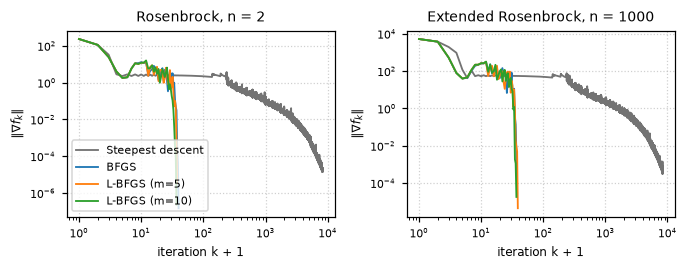

   n           method  iterations  f evals  g evals    status      final f
   2 Steepest descent        8261     8485     8390 converged 1.841973e-10
   2             BFGS          39       53       44 converged 1.101746e-17
   2     L-BFGS (m=5)          37       48       41 converged 1.977418e-13
   2    L-BFGS (m=10)          36       48       40 converged 4.889294e-17
1000 Steepest descent        8332     8541     8455 converged 1.221860e-07
1000             BFGS          37       55       45 converged 1.326196e-12
1000     L-BFGS (m=5)          38       53       44 converged 3.017032e-14
1000    L-BFGS (m=10)          36       50       43 converged 1.622266e-13


In [8]:
f_r, g_r, x0_r, _ = TEST_SET["ExtRosenbrock"]
METHODS_A = {"Steepest descent": dict(method="sd"), "BFGS": dict(method="bfgs"),
             "L-BFGS (m=5)": dict(method="lbfgs", m=5), "L-BFGS (m=10)": dict(method="lbfgs", m=10)}
conv_rows = []
fig, axes = plt.subplots(1, 2, figsize=(6.3, 2.5))
for ax, n_a, title in zip(axes, (2, 1000), ("Rosenbrock, n = 2", "Extended Rosenbrock, n = 1000")):
    for label, kw in METHODS_A.items():
        r = minimize(f_r, g_r, x0_r(n_a), **kw)
        ax.loglog(np.arange(1, len(r.gnorm_history) + 1), r.gnorm_history, label=label, color=COLORS[label])
        conv_rows.append({"n": n_a, "method": label, "iterations": r.iterations, "f evals": r.nfev,
                          "g evals": r.ngev, "status": r.status, "final f": r.f})
    ax.set_title(title)
    ax.set_xlabel("iteration k + 1")
    ax.set_ylabel(r"$\|\nabla f_k\|$")
axes[0].legend()
fig.tight_layout()
save_figure(fig, "convergence.pdf")
conv_table = pd.DataFrame(conv_rows)
print(conv_table.to_string(index=False))
RESULTS["convergence"] = conv_rows

### 5.2 Superlinear and linear rate

Error ratios $\|x_{k+1}-x^*\|/\|x_k-x^*\|$ on Rosenbrock ($n=2$, $x^*=(1,1)$), run to the tighter test
$\|\nabla f_k\|\le 10^{-10}\max(1,\|x_k\|)$ so that the tail is visible. Superlinear convergence means the ratios go to
$0$; for steepest descent they stay near a constant close to $1$, as expected from the condition number
$\kappa\approx 2.5\cdot10^3$ of $\nabla^2 f(x^*)$.

BFGS                  41 iterations, final ||x - x*|| = 6.0e-15, last ratios 0.1335, 0.02729, 0.0001323, 0.01718, 0.0008478
L-BFGS (m=5)          40 iterations, final ||x - x*|| = 3.0e-12, last ratios 0.1714, 0.01377, 0.004671, 0.2206, 0.002939
Steepest descent   18404 iterations, final ||x - x*|| = 3.3e-10, last ratios 0.9995, 0.9982, 0.9994, 0.9986, 0.9995
check: BFGS tail ratio (geometric mean of the last 5) = 0.0059 < 0.1 ✓
check: steepest descent ratio over the last 1000 iterations = 0.99891, constant near 1 ✓


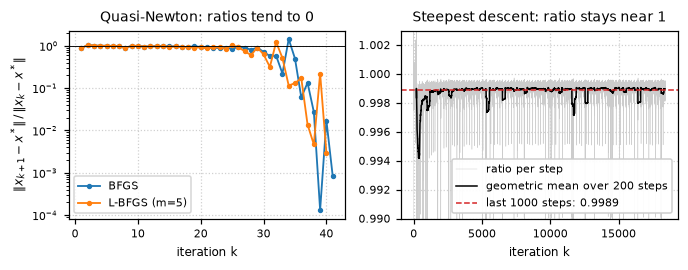

In [9]:
x_star_r = np.ones(2)
runs_b = {label: minimize(f_r, g_r, x0_r(2), keep_x=True, eps=1e-10, max_iter=30_000, **kw)
          for label, kw in {"BFGS": dict(method="bfgs"), "L-BFGS (m=5)": dict(method="lbfgs", m=5),
                            "Steepest descent": dict(method="sd")}.items()}
ratios = {}
for label, r in runs_b.items():
    err = np.linalg.norm(np.array(r.x_history) - x_star_r, axis=1)
    ratios[label] = err[1:] / err[:-1]
    print(f"{label:17s} {r.iterations:6d} iterations, final ||x - x*|| = {err[-1]:.1e}, last ratios "
          + ", ".join(f"{q:.4g}" for q in ratios[label][-5:]))

tail = {label: float(np.exp(np.mean(np.log(q[-5:])))) for label, q in ratios.items()}
sd_rate = float(np.exp(np.mean(np.log(ratios["Steepest descent"][-1000:]))))
hess = np.array([[802.0, -400.0], [-400.0, 200.0]])
kappa = float(np.linalg.cond(hess))
check(tail["BFGS"] < 0.1, f"BFGS tail ratio (geometric mean of the last 5) = {tail['BFGS']:.2g} < 0.1")
check(0.99 < sd_rate < 1.0, f"steepest descent ratio over the last 1000 iterations = {sd_rate:.5f}, constant near 1")

fig, axes = plt.subplots(1, 2, figsize=(6.3, 2.5))
for label in ("BFGS", "L-BFGS (m=5)"):
    axes[0].semilogy(np.arange(1, len(ratios[label]) + 1), ratios[label], "o-", ms=2.5, label=label, color=COLORS[label])
axes[0].axhline(1.0, color="k", lw=0.6)
axes[0].set_title("Quasi-Newton: ratios tend to 0")
axes[0].set_xlabel("iteration k")
axes[0].set_ylabel(r"$\|x_{k+1}-x^*\|\,/\,\|x_k-x^*\|$")
axes[0].legend()
q_sd = ratios["Steepest descent"]
window = 200
running = np.exp(np.convolve(np.log(q_sd), np.ones(window) / window, mode="valid"))
axes[1].plot(np.arange(1, len(q_sd) + 1), q_sd, color="0.8", lw=0.3, label="ratio per step")
axes[1].plot(np.arange(window, len(q_sd) + 1), running, color="k", lw=1.0, label=f"geometric mean over {window} steps")
axes[1].axhline(sd_rate, color="C3", lw=1.0, ls="--", label=f"last 1000 steps: {sd_rate:.4f}")
axes[1].set_ylim(0.99, 1.003)
axes[1].set_title("Steepest descent: ratio stays near 1")
axes[1].set_xlabel("iteration k")
axes[1].legend(loc="lower right", ncol=1, framealpha=0.95)
fig.tight_layout()
save_figure(fig, "rates.pdf")
RESULTS["rates"] = {"tail_ratio_geomean_last5": tail, "steepest_descent_ratio_last1000": sd_rate,
                    "hessian_condition_number_at_xstar": kappa,
                    "iterations": {label: r.iterations for label, r in runs_b.items()}}

### 5.3 Benchmark and performance profiles

All 15 functions at $n=100$ and $n=1000$: steepest descent (cap of 10 000 iterations), BFGS and L-BFGS ($m=5$). A
**performance profile** (Dolan and Moré 2002) plots, for each method, the fraction $\rho(\tau)$ of problems it solves
within a factor $\tau$ of the best method on that problem; $\rho(1)$ is the fraction where it is the best, and the right
end is the fraction solved. The time of each converged run is the minimum of three repeats.

Problems solved (of 15):
 method  BFGS  L-BFGS (m=5)  Steepest descent
n                                           
100       15            15                12
1000      15            15                 7 



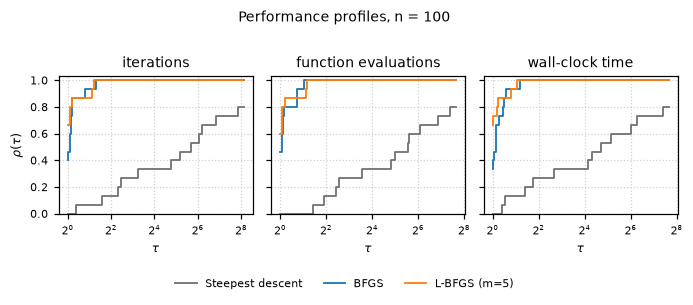

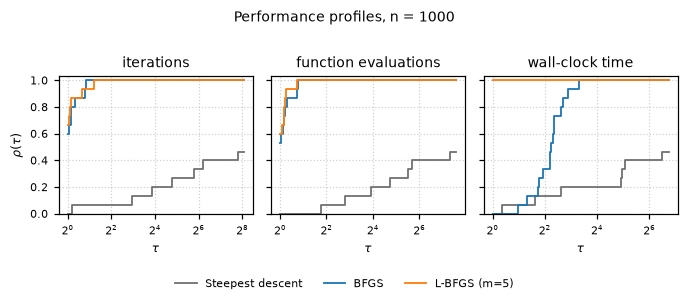

n =  100, iterations: best on Steepest descent 0%, BFGS 40%, L-BFGS (m=5) 67%
n =  100, f evals   : best on Steepest descent 0%, BFGS 47%, L-BFGS (m=5) 60%
n =  100, time      : best on Steepest descent 0%, BFGS 33%, L-BFGS (m=5) 67%
n = 1000, iterations: best on Steepest descent 0%, BFGS 60%, L-BFGS (m=5) 67%
n = 1000, f evals   : best on Steepest descent 0%, BFGS 53%, L-BFGS (m=5) 60%
n = 1000, time      : best on Steepest descent 0%, BFGS 0%, L-BFGS (m=5) 100%
check: BFGS solves 15/15 at n = 100 ✓
check: L-BFGS (m=5) solves 15/15 at n = 100 ✓
check: steepest descent solves 12/15 at n = 100 within 10 000 iterations ✓
check: BFGS solves 15/15 at n = 1000 ✓
check: L-BFGS (m=5) solves 15/15 at n = 1000 ✓
check: steepest descent solves 7/15 at n = 1000 within 10 000 iterations ✓
time BFGS / L-BFGS at n = 100: min 0.48 (DIXON3DQ), median 1.09, max 2.26; BFGS faster on: DIXON3DQ, TRIDIA, DQDRTIC, PertQuad, Diagonal1
time BFGS / L-BFGS at n = 1000: min 1.96 (TRIDIA), median 4.72, max 9.87; 

In [10]:
def run_benchmark(n, methods, repeats=3):
    rows = []
    for name, (f, g, x0f, src) in TEST_SET.items():
        x0 = x0f(n)
        for label, kw in methods.items():
            r = minimize(f, g, x0, **kw)
            t = r.time
            if r.converged:
                t = min([t] + [minimize(f, g, x0, **kw).time for _ in range(repeats - 1)])
            rows.append({"problem": name, "n": n, "method": label, "converged": r.converged, "status": r.status,
                         "iterations": r.iterations, "f evals": r.nfev, "g evals": r.ngev, "time": t,
                         "f": r.f, "gnorm": r.gnorm})
    return pd.DataFrame(rows)


def performance_profile(bench, metric, ax, title, order):
    cost = bench.pivot(index="problem", columns="method", values=metric).astype(float)[order]
    solved = bench.pivot(index="problem", columns="method", values="converged")[order]
    cost = cost.where(solved.astype(bool), np.inf)
    best = cost.min(axis=1)
    ratio = cost.div(best, axis=0).fillna(np.inf)
    finite_max = ratio.replace(np.inf, np.nan).max().max()
    taus = np.logspace(0, np.log2(max(2.0, 1.2 * finite_max)), 500, base=2)
    summary = {}
    for label in cost.columns:
        r = np.sort(ratio[label].to_numpy())
        ax.step(taus, np.searchsorted(r, taus, side="right") / len(r), where="post", label=label,
                color=COLORS.get(label))
        summary[label] = {"best_fraction": float(np.mean(r <= 1.0)), "solved_fraction": float(np.mean(np.isfinite(r)))}
    ax.set_xscale("log", base=2)
    ax.set_ylim(0, 1.03)
    ax.set_title(title)
    ax.set_xlabel(r"$\tau$")
    return summary


METHODS_C = {"Steepest descent": dict(method="sd"), "BFGS": dict(method="bfgs"),
             "L-BFGS (m=5)": dict(method="lbfgs", m=5)}
bench = pd.concat([run_benchmark(n, METHODS_C) for n in (100, 1000)], ignore_index=True)
success = bench.groupby(["n", "method"])["converged"].sum().unstack()
print("Problems solved (of 15):\n", success.to_string(), "\n")

profile_summary = {}
for n_c in (100, 1000):
    fig, axes = plt.subplots(1, 3, figsize=(6.3, 2.3), sharey=True)
    sub = bench[bench.n == n_c]
    profile_summary[n_c] = {
        metric: performance_profile(sub, metric, ax, title, list(METHODS_C))
        for ax, metric, title in zip(axes, ("iterations", "f evals", "time"), ("iterations", "function evaluations", "wall-clock time"))
    }
    axes[0].set_ylabel(r"$\rho(\tau)$")
    fig.suptitle(f"Performance profiles, n = {n_c}", y=1.02, fontsize=9)
    fig.tight_layout()
    fig.legend(*axes[0].get_legend_handles_labels(), loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.0), frameon=False)
    save_figure(fig, f"profiles_n{n_c}.pdf")

for n_c, by_metric in profile_summary.items():
    for metric, s in by_metric.items():
        print(f"n = {n_c:4d}, {metric:10s}: best on " + ", ".join(f"{k} {v['best_fraction']:.0%}" for k, v in s.items()))

for n_c in (100, 1000):
    for label in ("BFGS", "L-BFGS (m=5)"):
        check(success.loc[n_c, label] == 15, f"{label} solves 15/15 at n = {n_c}")
    check(success.loc[n_c, "Steepest descent"] < 15,
          f"steepest descent solves {success.loc[n_c, 'Steepest descent']}/15 at n = {n_c} within 10 000 iterations")

time_ratio = {}
for n_c in (100, 1000):
    t = bench[bench.n == n_c].pivot(index="problem", columns="method", values="time")
    r = (t["BFGS"] / t["L-BFGS (m=5)"]).sort_values()
    time_ratio[n_c] = {"min": float(r.min()), "median": float(r.median()), "max": float(r.max()),
                       "bfgs_faster_on": list(r[r < 1].index)}
    print(f"time BFGS / L-BFGS at n = {n_c}: min {r.min():.2f} ({r.index[0]}), median {r.median():.2f}, "
          f"max {r.max():.2f}; BFGS faster on: {', '.join(r[r < 1].index) or 'none'}")

per_problem = bench.pivot(index="problem", columns=["n", "method"], values="iterations")
print("\nIterations per problem (steepest descent capped at 10 000):\n", per_problem.to_string())
RESULTS["benchmark"] = {
    "success": {str(n): {k: int(v) for k, v in success.loc[n].items()} for n in (100, 1000)},
    "profiles": {str(n): v for n, v in profile_summary.items()},
    "time_ratio_bfgs_over_lbfgs": {str(n): v for n, v in time_ratio.items()},
    "runs": bench.to_dict(orient="records"),
}

### 5.4 L-BFGS memory

The same 15 problems at $n=1000$ with $m\in\{3,5,10,20\}$.

Totals over the 15 problems solved for every m:
 memory solved  total iterations  total f evals  total time (s)
 m = 3  15/15              9627          10413           0.952
 m = 5  15/15              7750           8604           0.788
m = 10  15/15              7466           8503           1.029
m = 20  15/15              7087           8144           1.437

Iterations per problem:
 method         m = 3  m = 5  m = 10  m = 20
problem                                    
ARWHEAD           11     11      11      11
BDQRTIC          229    121      70      76
DIXON3DQ        2315   1088    1052     825
DQDRTIC           15     13      13      13
Diagonal1        154    151     152     150
ExtBeale          14     14      14      14
ExtRosenbrock     39     38      36      35
ExtWhiteHolst     37     42      41      40
GenRosenbrock   5047   5028    4951    4950
LIARWHD           23     22      22      23
NONDIA            16     17      18      19
PertQuad         279    267     254   

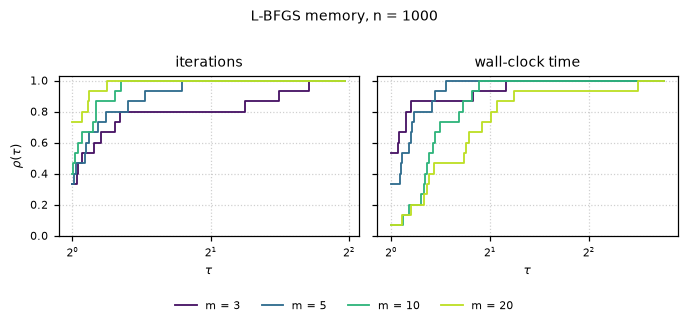

check: L-BFGS solves 15/15 at n = 1000 for every m ✓


In [11]:
METHODS_D = {f"m = {m}": dict(method="lbfgs", m=m) for m in (3, 5, 10, 20)}
mem = run_benchmark(1000, METHODS_D)
solved_all = mem.groupby("problem")["converged"].all()
common = solved_all[solved_all].index
mem_rows = []
for label in METHODS_D:
    sub = mem[mem.method == label]
    on_common = sub[sub.problem.isin(common)]
    mem_rows.append({"memory": label, "solved": f"{int(sub.converged.sum())}/15",
                     "total iterations": int(on_common.iterations.sum()), "total f evals": int(on_common["f evals"].sum()),
                     "total time (s)": round(float(on_common.time.sum()), 3)})
mem_table = pd.DataFrame(mem_rows)
print(f"Totals over the {len(common)} problems solved for every m:\n", mem_table.to_string(index=False))
print("\nIterations per problem:\n", mem.pivot(index="problem", columns="method", values="iterations")[list(METHODS_D)].to_string())

COLORS.update({label: plt.cm.viridis(v) for label, v in zip(METHODS_D, (0.05, 0.35, 0.65, 0.9))})
fig, axes = plt.subplots(1, 2, figsize=(6.3, 2.5), sharey=True)
mem_profiles = {metric: performance_profile(mem, metric, ax, title, list(METHODS_D))
                for ax, metric, title in zip(axes, ("iterations", "time"), ("iterations", "wall-clock time"))}
axes[0].set_ylabel(r"$\rho(\tau)$")
fig.suptitle("L-BFGS memory, n = 1000", y=1.02, fontsize=9)
fig.tight_layout()
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper center", ncol=4, bbox_to_anchor=(0.5, 0.0), frameon=False)
save_figure(fig, "memory.pdf")
check(all(mem.groupby("method").converged.sum() == 15), "L-BFGS solves 15/15 at n = 1000 for every m")
RESULTS["memory_study"] = {"totals_on_common_problems": mem_rows, "profiles": mem_profiles, "runs": mem.to_dict(orient="records"),
                           "iterations": mem.pivot(index="problem", columns="method", values="iterations").to_dict()}

### 5.5 Large scale

L-BFGS ($m=5$) on Extended Rosenbrock for $n=10^3,\dots,10^6$. With Vilin's starting point all $n/2$ two-dimensional
blocks start equal, so every block follows the same iterates and the problem behaves like the two-dimensional one; only
the first trial step $\min(1,1/\|\nabla f_0\|)$ depends on $n$. A second run
therefore starts from Vilin's point plus a fixed random perturbation $0.1\,\mathcal{N}(0,1)$, so the blocks differ. Full
BFGS would have to store $n^2$ numbers, which is $8n^2$ bytes.

      n           start  iterations  f evals  g evals  time (s)      final f  converged  BFGS matrix (GB)  L-BFGS pairs (MB)
   1000     Vilin start          38       53       44     0.006 3.017032e-14       True             0.008               0.08
   1000 perturbed start         175      201      179     0.040 9.043839e-10       True             0.008               0.08
  10000     Vilin start          35       49       42     0.031 7.696974e-11       True             0.800               0.80
  10000 perturbed start         561      655      582     0.254 2.295524e-07       True             0.800               0.80
 100000     Vilin start          41       63       49     0.114 1.254349e-11       True            80.000               8.00
 100000 perturbed start        1089     1307     1105     2.866 6.764944e-09       True            80.000               8.00
1000000     Vilin start          39       60       49     1.092 2.035413e-11       True          8000.000              80.00


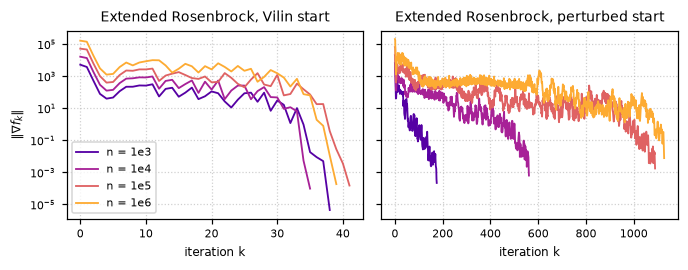

check: L-BFGS converges for every n up to 10^6, from both starts ✓
check: n = 10^6 from Vilin's start takes 1.09 s (full BFGS would need 8 TB) ✓


In [12]:
rng = np.random.default_rng(5)
large_rows, large_hist = [], {}
for n_e in (10**3, 10**4, 10**5, 10**6):
    starts = {"Vilin start": x0_r(n_e), "perturbed start": x0_r(n_e) + 0.1 * rng.standard_normal(n_e)}
    for start, x0 in starts.items():
        r = minimize(f_r, g_r, x0, method="lbfgs", m=5)
        large_hist[(start, n_e)] = r.gnorm_history
        large_rows.append({"n": n_e, "start": start, "iterations": r.iterations, "f evals": r.nfev, "g evals": r.ngev,
                           "time (s)": round(r.time, 3), "final f": r.f, "converged": r.converged,
                           "BFGS matrix (GB)": 8 * n_e**2 / 1e9, "L-BFGS pairs (MB)": 2 * 5 * n_e * 8 / 1e6})
large = pd.DataFrame(large_rows)
print(large.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(6.3, 2.5), sharey=True)
for ax, start in zip(axes, ("Vilin start", "perturbed start")):
    for j, n_e in enumerate((10**3, 10**4, 10**5, 10**6)):
        h = large_hist[(start, n_e)]
        ax.semilogy(np.arange(len(h)), h, label=f"n = 1e{int(np.log10(n_e))}", color=plt.cm.plasma(0.15 + 0.22 * j))
    ax.set_title(f"Extended Rosenbrock, {start}")
    ax.set_xlabel("iteration k")
axes[0].set_ylabel(r"$\|\nabla f_k\|$")
axes[0].legend()
fig.tight_layout()
save_figure(fig, "large_scale.pdf")
check(large.converged.all(), "L-BFGS converges for every n up to 10^6, from both starts")
t_1e6 = large[(large.n == 10**6) & (large.start == "Vilin start")]["time (s)"].iloc[0]
check(t_1e6 < 30, f"n = 10^6 from Vilin's start takes {t_1e6:.2f} s (full BFGS would need {8e12 / 1e12:.0f} TB)")
RESULTS["large_scale"] = large_rows

### 5.6 Comparison with SciPy's L-BFGS-B

SciPy's `L-BFGS-B` (Byrd, Lu, Nocedal and Zhu 1995) with the same memory $m=5$, on four problems with a unique, known
minimizer ($n=1000$). The question is whether both codes reach the same minimizer in a comparable number of iterations.

In [13]:
n_f = 1000
x_star = {"ExtRosenbrock": np.ones(n_f), "ExtBeale": np.resize([3.0, 0.5], n_f),
          "TRIDIA": 0.5 ** np.arange(n_f), "Diagonal1": np.log(np.arange(1, n_f + 1))}
cmp_rows = []
for name, xs in x_star.items():
    f, g, x0f, src = TEST_SET[name]
    ours = minimize(f, g, x0f(n_f), method="lbfgs", m=5)
    sp = scipy.optimize.minimize(f, x0f(n_f), jac=g, method="L-BFGS-B",
                                 options={"maxcor": 5, "gtol": 1e-6, "ftol": 1e-15, "maxiter": 10_000, "maxfun": 100_000})
    cmp_rows.append({"problem": name, "ours: iterations": ours.iterations, "SciPy: iterations": int(sp.nit),
                     "ours: |x - x*|_inf": float(np.max(np.abs(ours.x - xs))), "SciPy: |x - x*|_inf": float(np.max(np.abs(sp.x - xs))),
                     "|ours - SciPy|_inf": float(np.max(np.abs(ours.x - sp.x))), "SciPy message": str(sp.message)})
cmp_table = pd.DataFrame(cmp_rows)
print(cmp_table.drop(columns="SciPy message").to_string(index=False, float_format=lambda v: f"{v:.1e}"))
for row in cmp_rows:
    check(row["ours: |x - x*|_inf"] <= 1e-3 and row["SciPy: |x - x*|_inf"] <= 1e-3,
          f"{row['problem']}: both reach x* (ours {row['ours: |x - x*|_inf']:.1e}, SciPy {row['SciPy: |x - x*|_inf']:.1e})")
    ratio = row["ours: iterations"] / row["SciPy: iterations"]
    check(1 / 3 <= ratio <= 3, f"{row['problem']}: iteration counts of the same order ({row['ours: iterations']} vs {row['SciPy: iterations']})")
RESULTS["scipy_comparison"] = cmp_rows

      problem  ours: iterations  SciPy: iterations  ours: |x - x*|_inf  SciPy: |x - x*|_inf  |ours - SciPy|_inf
ExtRosenbrock                38                 38             1.3e-08              1.6e-09             1.1e-08
     ExtBeale                14                 16             1.7e-07              1.6e-09             1.7e-07
       TRIDIA               723                712             9.2e-08              2.5e-07             1.6e-07
    Diagonal1               151                168             1.5e-04              9.8e-05             2.5e-04
check: ExtRosenbrock: both reach x* (ours 1.3e-08, SciPy 1.6e-09) ✓
check: ExtRosenbrock: iteration counts of the same order (38 vs 38) ✓
check: ExtBeale: both reach x* (ours 1.7e-07, SciPy 1.6e-09) ✓
check: ExtBeale: iteration counts of the same order (14 vs 16) ✓
check: TRIDIA: both reach x* (ours 9.2e-08, SciPy 2.5e-07) ✓
check: TRIDIA: iteration counts of the same order (723 vs 712) ✓
check: Diagonal1: both reach x* (ours 1.5e-04, S

In [14]:
RESULTS["runtime_seconds"] = round(time.perf_counter() - NOTEBOOK_START, 1)


def to_jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, (np.bool_, bool)):
        return bool(obj)
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, (np.floating, float)):
        return None if not np.isfinite(obj) else float(obj)
    return obj


Path("results.json").write_text(json.dumps(to_jsonable(RESULTS), indent=1, ensure_ascii=False))
print(f"results.json written; figures: {sorted(p.name for p in FIG_DIR.glob('*.pdf'))}")
print(f"total runtime: {RESULTS['runtime_seconds']} s")

results.json written; figures: ['convergence.pdf', 'large_scale.pdf', 'memory.pdf', 'profiles_n100.pdf', 'profiles_n1000.pdf', 'rates.pdf']
total runtime: 90.9 s


## 6. Conclusion

* **The implementation matches the theory.** The worked update of the seminar paper is reproduced exactly, with
  eigenvalues 0.3596 and 1.3904. On 1000 random pairs with $s^\top y>0$ the BFGS update stays symmetric (error
  $4.2\cdot10^{-16}$), satisfies the secant equation (residual $4.3\cdot10^{-13}$) and stays positive definite. The
  two-loop recursion agrees with the explicit matrix to $2.9\cdot10^{-15}$.
* **The test set is verified.** All 15 ported gradients agree with central finite differences (worst
  $7.1\cdot10^{-10}$) and with automatic differentiation (worst $3.7\cdot10^{-16}$). Vilin's ARWHEAD gradient is exact
  only for $n=3$; for $n=10$ its last component is wrong and the gradient differs by 31%.
* **Stopping test.** A test relative to $\|\nabla f_0\|$ accepted $f=6.3\cdot10^{-3}$ on NONDIA, and the absolute test
  $\|\nabla f\|_\infty\le10^{-6}$ stalled on roundoff near the solution on three problems. The low-accuracy test
  $\|\nabla f_k\|\le10^{-5}\max(1,\|x_k\|)$ of Liu and Nocedal is met before such stalls.
* **Superlinear against linear.** On Rosenbrock BFGS needs 39 iterations, L-BFGS 37 and steepest descent 8261. Near the
  solution the BFGS error ratios fall to a geometric mean of 0.0059 over the last five steps, consistent with
  superlinear convergence, while steepest descent settles at 0.9989 per step, as expected from
  $\kappa(\nabla^2 f(x^*))\approx 2508$.
* **Robustness.** BFGS and L-BFGS solve all 15 problems at $n=100$ and $n=1000$. Steepest descent solves 12 and 7 of
  them within 10 000 iterations. The hardest problem is the chained GenRosenbrock (5607 BFGS and 5028 L-BFGS iterations
  at $n=1000$).
* **Cost.** By iterations and by function evaluations BFGS and L-BFGS are close: L-BFGS is the best or tied on 67% of
  the problems by iterations at both sizes, BFGS on 40% at $n=100$ and 60% at $n=1000$. By time, L-BFGS is faster than
  BFGS on every problem at $n=1000$ in the reported run (ratios printed in 5.3), because a BFGS iteration costs $O(n^2)$ and an L-BFGS iteration
  $O(mn)$.
* **Memory $m$.** More pairs save iterations mainly on the ill-conditioned quadratics (TRIDIA 1194 to 503, DIXON3DQ
  2315 to 825 from $m=3$ to $m=20$). The total iterations fall from 9627 to 7087, but the total time is lowest around
  $m=3$ to $5$, Vilin's default being $m=5$.
* **Large scale.** L-BFGS solves Extended Rosenbrock with $n=10^6$ in 39 iterations from Vilin's start (the two-dimensional
  problem replicated) and in 1127 from the perturbed start, storing about 80 MB of pairs; full BFGS would need 8 TB for its matrix.
* **Agreement with SciPy.** On four problems with known minimizers our L-BFGS and SciPy's L-BFGS-B reach the same point
  (within $2.5\cdot10^{-4}$ on Diagonal1 and $2\cdot10^{-7}$ or better on the other three) in comparable iteration counts: 38/38, 14/16, 723/712 and 151/168.

## References

* N. Andrei, An unconstrained optimization test functions collection, *Adv. Model. Optim.* 10 (2008) 147–161.
* I. Bongartz, A. R. Conn, N. Gould, Ph. L. Toint, CUTE: constrained and unconstrained testing environment, *ACM Trans.
  Math. Softw.* 21 (1995) 123–160.
* R. H. Byrd, P. Lu, J. Nocedal, C. Zhu, A limited memory algorithm for bound constrained optimization, *SIAM J. Sci.
  Comput.* 16 (1995) 1190–1208.
* J. E. Dennis, J. J. Moré, Quasi-Newton methods, motivation and theory, *SIAM Review* 19 (1977) 46–89.
* E. D. Dolan, J. J. Moré, Benchmarking optimization software with performance profiles, *Math. Program.* 91 (2002) 201–213.
* D. C. Liu, J. Nocedal, On the limited memory BFGS method for large scale optimization, *Math. Program.* 45 (1989) 503–528.
* M. Miladinović, P. Stanimirović, *Nelinearna optimizacija*, Univerzitet u Nišu, 2015.
* M. Miladinović, P. Živadinović, Vilin: Unconstrained Numerical Optimization Application, arXiv:1812.10986, 2018.
* J. J. Moré, D. J. Thuente, Line search algorithms with guaranteed sufficient decrease, *ACM Trans. Math. Softw.* 20
  (1994) 286–307.
* J. Nocedal, S. J. Wright, *Numerical Optimization*, 2nd ed., Springer, 2006.
* P. Živadinović, M. Miladinović, Vilin: application and framework for numerical optimization (MATLAB),
  github.com/markomil/vilin-numerical-optimization.